# Joint Fisher Forecast: PFS + DESI-DR2 BAO + BBN+$n_s$ ($\Lambda$CDM)

Combined Fisher forecast from full-shape, BAO, and external-prior information:
- **PFS full-shape** $P_\ell(k) + B_0$ (7 redshift bins, $\ell = 0, 2, 4$, with AP effect)
- **DESI DR2 BAO** (13 data points across 7 redshift bins)
- **External priors**: BBN prior on $\omega_b$ and Gaussian prior on $n_s$

Neutrino mass is **fixed** at $m_\nu = 0.06\,$eV (not varied).

**Forecast basis**: $(\omega_b, \omega_c, \log A, n_s, h)$ — 5 parameters after marginalising PFS survey parameters.

In [1]:
import os
from pathlib import Path

os.environ.setdefault('MPLCONFIGDIR', '/tmp/matplotlib-jaxptpolypol')
Path(os.environ['MPLCONFIGDIR']).mkdir(parents=True, exist_ok=True)

import matplotlib
%matplotlib inline
%config InlineBackend.figure_format = 'retina'
import matplotlib.pyplot as plt
plt.rcParams.update({
    "text.usetex": True,
    "font.family": "sans-serif",
    "font.sans-serif": "Computer Modern",
    "font.size": 22,
})
import matplotlib.lines as mlines

import numpy as np
import jax
jax.config.update("jax_enable_x64", True)
import jax.numpy as jnp
from jax.scipy.linalg import inv

from ps_1loop_jax import background as bg

from jaxptpolypol.model import BispectrumTreeModel, CosmoEmulator, PS1LoopModel
from jaxptpolypol.params import (
    CosmoParams,
    FullShapeSurveyParams,
    pack_joint_params,
    pack_pk_params,
    unpack_joint_params,
    unpack_pk_params,
)
from jaxptpolypol.inference import (
    fisher_matrix,
    marginalize_fisher,
    marginalized_fisher_block,
    sigma_from_fisher,
    fixed_and_varied_indices,
    gaussian_prior_fisher,
    build_prior_sigmas,
    project_fisher_to_derived,
    fisher_diagnostics,
    format_fisher_diagnostics,
)
from jaxptpolypol.plotting import plot_contours, plot_Gaussian
from jaxptpolypol.theory import (
    build_bispectrum_triangles_from_k_grid,
    compute_fiducial_distances,
    make_gaussian_joint_covariance_fn,
    make_joint_pk_bk_fn,
)
from jaxptpolypol.bao import load_desi_dr2, bao_fisher_matrix, add_bao_to_fullshape_fisher
from jaxptpolypol.marginalization import make_lcdm_corner_specs, project_case_to_specs


## Configuration

In [2]:
# ── Unified fiducial cosmology (Planck 2018 TT,TE,EE+lowE+lensing+BAO) ──
FIDUCIAL = {
    'ombh2': 0.02242, 'omch2': 0.11933, 'logA': 3.047,
    'ns': 0.9665, 'h': 0.6766, 'tau': 0.0561,
}
MNU_FIXED = 0.06  # eV, not varied in LCDM

# ── PFS survey config ──
z_bins   = (0.7,  0.9,  1.1,  1.3,  1.5,  1.8,  2.2)
V_bins   = tuple(v * 1000.**3 for v in (0.59, 0.79, 0.96, 1.09, 1.19, 2.58, 2.71))
knl_bins = (0.52, 0.65, 0.82, 1.02, 1.29, 1.82, 2.88)
n_bar    = (3.06e-4, 9.61e-4, 9.75e-4, 6.54e-4, 3.40e-4, 2.02e-4, 3.51e-4)
n_zbins  = len(z_bins)

# ── Bispectrum / joint P+B config (matches fisher_multibin_*_AP_PB.ipynb) ──
K_PK_MIN, K_PK_MAX, N_K = 0.02, 0.20, 37
K_BK_MIN, K_BK_MAX = 0.02, 0.08
K_NL_RSD = 0.45
NUM_MU = NUM_PHI = 65
N_GL = 16
BB_POWER_MODEL = 'kaiser'   # C_BB from Kaiser P_ell; set '1loop' to reuse the 1-loop P_ell
BACKGROUND_MODE = 'direct'


# ── PFS emulator ──
PFS_EMULATOR = '/Users/nguyenmn/cosmopower-jax-for-pfs/cosmology/jense2024/jense_2023_camb_lcdm/networks/jense_2023_camb_lcdm_Pk_lin.npz'

# ── BAO data ──
BAO_DATA_DIR = "../../ext_data/bao_data/desi_bao_dr2"

# ── Forecast basis ──
SHARED_KEYS = ('ombh2', 'omch2', 'logA', 'ns', 'h')
N_SHARED = len(SHARED_KEYS)
SHARED_LABELS = (r'$\omega_b$', r'$\omega_c$', r'$\log A$', r'$n_s$', r'$h$')
FIDUCIAL_SHARED = np.array([FIDUCIAL[k] for k in SHARED_KEYS])

# ── Priors (BBN + ns) ──
COSMO_PRIORS = {'ombh2': 0.00055, 'ns': 0.042}  # BBN + ns10 (DESI convention, arXiv:2411.12022)

print("Unified fiducial:", FIDUCIAL)
print("Forecast basis:", SHARED_KEYS)
print(f"Applied priors: ombh2 sigma={COSMO_PRIORS['ombh2']}, ns sigma={COSMO_PRIORS['ns']}")
MODEL_TITLE = r'$\Lambda$CDM'

Unified fiducial: {'ombh2': 0.02242, 'omch2': 0.11933, 'logA': 3.047, 'ns': 0.9665, 'h': 0.6766, 'tau': 0.0561}
Forecast basis: ('ombh2', 'omch2', 'logA', 'ns', 'h')
Applied priors: ombh2 sigma=0.00055, ns sigma=0.042


## Part 1 — PFS Full-Shape Fisher

In [3]:
# ── Emulator and models ──
pklin_emulator = CosmoEmulator(probe='custom_log', emulator_path=PFS_EMULATOR)
ps1loop_model = PS1LoopModel(do_irres=True)
bispectrum_model = BispectrumTreeModel(do_AP=True, k_nl_rsd=K_NL_RSD)

# ── Fiducial cosmology (PFS basis) ──
cosmo_dict = {
    'ombh2': FIDUCIAL['ombh2'], 'omch2': FIDUCIAL['omch2'],
    'logA':  FIDUCIAL['logA'],  'ns':    FIDUCIAL['ns'],
    'h':     FIDUCIAL['h'],
    'z':     0.7,       # placeholder; overridden per bin
    'A_b':   3.13, 'eta_b': 0.603, 'logT_AGN': 7.8,
}
cosmo = CosmoParams(cosmo_dict)

# ── Bias fitting functions (arXiv:1907.06666) ──
def b1z(z): return 0.9 + 0.4 * z
def b2z(z): return -0.704 - 0.208 * z + 0.183 * z**2 - 0.00771 * z**3
def bG2z(z): return -(2. / 7.) * (b1z(z) - 1.)
def bGamma3z(z): return (23. / 42.) * (b1z(z) - 1.)

def Dplusz(z):
    return float(bg.growth_factor(
        cosmo_dict['ombh2'], cosmo_dict['omch2'], cosmo_dict['h'], z, mnu=MNU_FIXED,
    ))

def c0z(z): return 25. * Dplusz(z)**2
def c2z(z): return 25. * Dplusz(z)**2
def c4z(z): return Dplusz(z)**2

# ── Survey parameters per bin (P + B blocks) ──
surveys = []
for i, (z, knl, nd) in enumerate(zip(z_bins, knl_bins, n_bar)):
    s = FullShapeSurveyParams(
        shared={
            'bias': {'b1': b1z(z), 'b2': b2z(z), 'bG2': bG2z(z), 'bGamma3': bGamma3z(z)},
            'stoch': {'P_shot': 1.0},
            'k_nl': knl, 'ndens': nd,
        },
        pk={
            'ctr': {'c0': c0z(z), 'c2': c2z(z), 'c4': c4z(z), 'cfog': knl**(-4)},
            'stoch': {'a0': 0., 'a2': 0.},
        },
        bk={
            'ctr': {'c1': 0.0},
            'stoch': {'B_shot': 1.0, 'A_shot': 1.0},
        },
    )
    surveys.append(s)

joint_survey_keys = surveys[0].joint_param_keys

# ── Pack parameters (cosmo + joint P+B survey blocks) ──
packed_params = pack_joint_params(cosmo, surveys)
n_cosmo_params = sum(cosmo.param_sizes)
n_survey_params = len(joint_survey_keys)
print(f"Total parameters: {packed_params.shape[0]} ({n_cosmo_params} cosmo + {n_survey_params}×{n_zbins} survey)")

# ── Fiducial distances ──
Hz_fid, DAz_fid = compute_fiducial_distances(cosmo, z_bins)
for z, Hz_val, DAz_val in zip(z_bins, Hz_fid, DAz_fid):
    print(f"  z={z}: H(z)={Hz_val:.2f} km/s/Mpc, D_A(z)={DAz_val:.2f} Mpc")


Tried to load pickle file from pre-trained model, but failed.
This usually means that you have TF>=2.14, or that you are loading a model that was trained on PCA but loaded with the log (or viceversa), or that you are loading a non-standard model from the cosmopower-organization repo.
Falling back to the dictionary, in case this also fails or does not output the right shape make sure you ran the `convert_tf214.py` script, and that a `.npz` file exists among the trained models, and that you ran `pip install .`. Also make sure that you are asking for the right probe between `custom_log` and `custom_pca`.


Total parameters: 121 (9 cosmo + 16×7 survey)
  z=0.7: H(z)=100.75 km/s/Mpc, D_A(z)=1517.28 Mpc
  z=0.9: H(z)=113.67 km/s/Mpc, D_A(z)=1652.58 Mpc
  z=1.1: H(z)=127.83 km/s/Mpc, D_A(z)=1732.11 Mpc
  z=1.3: H(z)=143.10 km/s/Mpc, D_A(z)=1774.25 Mpc
  z=1.5: H(z)=159.38 km/s/Mpc, D_A(z)=1791.13 Mpc
  z=1.8: H(z)=185.51 km/s/Mpc, D_A(z)=1786.02 Mpc
  z=2.2: H(z)=223.19 km/s/Mpc, D_A(z)=1746.91 Mpc


In [4]:
# ── Differentiable joint P+B wrapper ──
joint_fn = make_joint_pk_bk_fn(
    pklin_emulator=pklin_emulator,
    ps1loop_model=ps1loop_model,
    bispectrum_model=bispectrum_model,
    cosmo_keys=cosmo.param_keys,
    cosmo_sizes=cosmo.param_sizes,
    survey_keys=joint_survey_keys,
    ap=True,
    z_bins=z_bins,
    Hz_fid=Hz_fid,
    DAz_fid=DAz_fid,
    n_gl=N_GL,
    num_mu=NUM_MU,
    num_phi=NUM_PHI,
    background_mode=BACKGROUND_MODE,
)
joint_cov_fn = make_gaussian_joint_covariance_fn(
    pklin_emulator=pklin_emulator,
    ps1loop_model=ps1loop_model,
    cosmo_keys=cosmo.param_keys,
    cosmo_sizes=cosmo.param_sizes,
    survey_keys=joint_survey_keys,
    ap=True,
    z_bins=z_bins,
    Hz_fid=Hz_fid,
    DAz_fid=DAz_fid,
    bb_power_model=BB_POWER_MODEL,
    n_gl=N_GL,
    background_mode=BACKGROUND_MODE,
)
jitted_joint_fn = jax.jit(joint_fn)

# ── k grid and bispectrum triangles (same dk; canonical triangles inside (K_BK_MIN, K_BK_MAX)) ──
k = jnp.linspace(K_PK_MIN, K_PK_MAX, N_K)
dk = float(k[1] - k[0])
n_k = int(k.shape[0])
triangles, triangle_dk = build_bispectrum_triangles_from_k_grid(
    k, k_min=K_BK_MIN, k_max=K_BK_MAX, dk=dk,
)
n_tri = int(triangles.shape[0])
print(f"P grid: n_k={n_k}, dk={dk:.5f}; B triangles in ({K_BK_MIN}, {K_BK_MAX}): {n_tri}")

# ── Jacobian of the joint data vector ──
jitted_joint_fn(packed_params, k=k, triangles=triangles).block_until_ready()  # JIT warmup
%time jac = jax.jacfwd(jitted_joint_fn, argnums=0)(packed_params, k=k, triangles=triangles)
print(f"Per-bin joint block: 3*{n_k} + {n_tri}; Jacobian shape: {jac.shape}")

# ── Joint Gaussian covariance (C_PP + C_BB; C_PB currently zero in the library) ──
gauss_cov = joint_cov_fn(
    packed_params,
    V_survey=V_bins,
    k=k,
    dk=dk,
    triangles=triangles,
    triangle_dk=triangle_dk,
)

# ── PFS P+B Fisher matrix ──
F_pfs_full = fisher_matrix(gauss_cov, jac)
print(f"PFS P+B Fisher shape: {F_pfs_full.shape}")


P grid: n_k=37, dk=0.00500; B triangles in (0.02, 0.08): 264


CPU times: user 14min 7s, sys: 4min 3s, total: 18min 10s
Wall time: 2min 33s
Per-bin joint block: 3*37 + 264; Jacobian shape: (2625, 121)


PFS P+B Fisher shape: (121, 121)


## Part 2 — DESI DR2 BAO Fisher

In [5]:
bao_dr2 = load_desi_dr2("all", data_dir=BAO_DATA_DIR)
fiducial_cosmo = packed_params[:n_cosmo_params]

F_bao = bao_fisher_matrix(
    bao_dr2, fiducial_cosmo,
    cosmo_keys=cosmo.param_keys, cosmo_sizes=cosmo.param_sizes,
)
F_pfs_bao_full = add_bao_to_fullshape_fisher(F_pfs_full, F_bao, n_cosmo=n_cosmo_params)

print(f"DESI DR2 BAO data points: {len(bao_dr2.data_points)}")
print(f"BAO Fisher shape: {F_bao.shape}")

DESI DR2 BAO data points: 13
BAO Fisher shape: (9, 9)


## Part 3 — External Priors (BBN + $n_s$)

In [6]:
# ── EFT/stochastic survey priors: DESI DR1-reanalysis spec (arXiv:2511.20757 Table I) ──
# Migrated from the legacy Eq.(12) spec (eft_eq12_2405_02252). Fisher priors are the
# FIDUCIAL (R=1) DESI widths; the c0/c2/c4 counterterm trio carries the MARGINAL widths
# of the correlated prior (off-diagonal correlations live only in the MCMC-side Sigma_p).
# DESI carries bGamma3 width 1.0 natively; b2/bG2 ~ 5/sigma8(z)^2; b1 flat (no prior).
# See docs/design/desi-convention-map.md.
from jaxptpolypol.inference import build_prior_sigmas
from jaxptpolypol.desi_priors import (
    load_desi_prior_spec, make_lcdm_rescaling_fns, build_prior_sigmas_from_desi_spec,
)
desi_spec = load_desi_prior_spec()  # desi_dr1_reanalysis_2511_20757
assert desi_spec.marginalized[('shared', 'bias', 'bGamma3')].sigma == 1.0
_s8_keys = ('ombh2', 'omch2', 'logA', 'ns', 'h')
_, _, sigma8_ref_bins = make_lcdm_rescaling_fns(
    pklin_emulator=pklin_emulator,
    cosmo_keys=_s8_keys, cosmo_sizes=(1,) * len(_s8_keys),
    z_bins=z_bins,
    fid_cosmo_native=jnp.array([cosmo_dict[k] for k in _s8_keys]),
    mnu_fixed=float(cosmo_dict.get('mnu', 0.06)),
    fixed_cosmo_extras={'A_b': cosmo_dict['A_b'], 'eta_b': cosmo_dict['eta_b'],
                        'logT_AGN': cosmo_dict['logT_AGN']},
)
_survey_sigma_dicts, _sampled_sigma_bins = build_prior_sigmas_from_desi_spec(
    desi_spec, knl_bins=knl_bins, sigma8_ref_bins=sigma8_ref_bins,
)
desi_survey_priors = []
for _b in range(n_zbins):
    _d = dict(_survey_sigma_dicts[_b])
    _d[('shared', 'bias', 'b2')] = _sampled_sigma_bins[_b]['b2']
    _d[('shared', 'bias', 'bG2')] = _sampled_sigma_bins[_b]['bG2']
    desi_survey_priors.append(_d)
prior_sigmas = build_prior_sigmas(
    cosmo_keys=cosmo.param_keys,
    cosmo_sizes=cosmo.param_sizes,
    survey_keys=joint_survey_keys,
    n_bins=n_zbins,
    cosmo_priors=COSMO_PRIORS,
    survey_priors=desi_survey_priors,
)
F_prior = gaussian_prior_fisher(packed_params.shape[0], prior_sigmas)

F_pfs_prior_full = F_pfs_full + F_prior
F_pfs_bao_prior_full = F_pfs_bao_full + F_prior

print(f"Applied priors: ombh2 σ={COSMO_PRIORS['ombh2']}, ns σ={COSMO_PRIORS['ns']} (ns10), "
      "plus DESI DR1-reanalysis EFT/stochastic priors (arXiv:2511.20757 Table I)")

Applied priors: ombh2 σ=0.00055, ns σ=0.042 (ns10), plus DESI DR1-reanalysis EFT/stochastic priors (arXiv:2511.20757 Table I)


## Part 4 — Marginalise PFS survey parameters

In [7]:
# ── Remove truly fixed parameters ──
fixed_cosmo = [5, 6, 7, 8]  # z, A_b, eta_b, logT_AGN
fixed_survey_keys = {('shared', 'k_nl', None), ('shared', 'ndens', None)}
fixed_survey_offsets = [i for i, key in enumerate(joint_survey_keys) if key in fixed_survey_keys]

fixed_idx, varied_idx = fixed_and_varied_indices(
    n_cosmo_params, n_survey_params, n_zbins, fixed_cosmo, fixed_survey_offsets,
)
print(f"Fixed: {len(fixed_idx)}, Varied: {len(varied_idx)}")

# ── Cosmo indices within the varied subvector ──
# PFS varied cosmo: ombh2(0), omch2(1), logA(2), ns(3), h(4)
cosmo_varied_global = [i for i in range(n_cosmo_params) if i not in fixed_cosmo]
cosmo_varied_marg = [list(varied_idx).index(i) for i in cosmo_varied_global]
n_pfs_cosmo = len(cosmo_varied_marg)  # 5
print(f"PFS varied cosmo params: {n_pfs_cosmo}, indices in marg vector: {cosmo_varied_marg}")

# ── Marginalise each case to cosmo-only ──
F_pfs_cosmo = marginalized_fisher_block(
    marginalize_fisher(F_pfs_full, varied_idx), cosmo_varied_marg,
)
F_pfs_bao_cosmo = marginalized_fisher_block(
    marginalize_fisher(F_pfs_bao_full, varied_idx), cosmo_varied_marg,
)
F_pfs_prior_cosmo = marginalized_fisher_block(
    marginalize_fisher(F_pfs_prior_full, varied_idx), cosmo_varied_marg,
)
F_pfs_bao_prior_cosmo = marginalized_fisher_block(
    marginalize_fisher(F_pfs_bao_prior_full, varied_idx), cosmo_varied_marg,
)
print(f"PFS cosmo-only Fisher shape: {F_pfs_cosmo.shape}")

Fixed: 18, Varied: 103
PFS varied cosmo params: 5, indices in marg vector: [0, 1, 2, 3, 4]
PFS cosmo-only Fisher shape: (5, 5)


## Results

In [8]:
# ── Compute marginalized 1sigma constraints in the forecast basis ──
def safe_sigma(F):
    try:
        cov = np.linalg.inv(0.5 * (F + F.T))
        d = np.diag(cov)
        return np.where(d > 0, np.sqrt(d), np.inf)
    except np.linalg.LinAlgError:
        cov = np.linalg.pinv(0.5 * (F + F.T))
        d = np.diag(cov)
        return np.where(d > 0, np.sqrt(d), np.inf)

cases = {
    'PFS P+B':                 np.asarray(F_pfs_cosmo),
    'PFS P+B+BBN+ns':          np.asarray(F_pfs_prior_cosmo),
    'PFS P+B+BAO':             np.asarray(F_pfs_bao_cosmo),
    'PFS P+B+BAO+BBN+ns':      np.asarray(F_pfs_bao_prior_cosmo),
}
sigmas = {label: safe_sigma(F) for label, F in cases.items()}

header = f"{'Param':>8s}  {'Fiducial':>10s}"
for label in cases:
    header += f"  {label:>16s}"
print(header)
print("-" * len(header))
for i, key in enumerate(SHARED_KEYS):
    row = f"{key:>8s}  {FIDUCIAL_SHARED[i]:10.5g}"
    for label in cases:
        s = sigmas[label][i]
        row += f"  {s:16.5g}" if np.isfinite(s) else f"  {'---':>16s}"
    print(row)

   Param    Fiducial           PFS P+B    PFS P+B+BBN+ns       PFS P+B+BAO  PFS P+B+BAO+BBN+ns
----------------------------------------------------------------------------------------------
   ombh2     0.02242         0.0048267        0.00054471         0.0010486        0.00048211
   omch2     0.11933          0.012557         0.0055707         0.0039252          0.003422
    logA       3.047            0.1238          0.072171          0.091656          0.062477
      ns      0.9665          0.094722          0.032134          0.083175          0.027963
       h      0.6766          0.013732         0.0040125         0.0062662         0.0036491


In [9]:
# Projected constraints on standard parameters
def projected_sigmas_from_fisher(fisher, rcond=1e-12):
    fisher = np.asarray(fisher, dtype=float)
    fisher = 0.5 * (fisher + fisher.T)
    eigvals = np.linalg.eigvalsh(fisher)
    scale = max(float(np.max(np.abs(eigvals))) if eigvals.size else 0.0, 1.0)
    if np.count_nonzero(eigvals > rcond * scale) < fisher.shape[0]:
        return np.full(fisher.shape[0], np.inf)
    cov = np.linalg.inv(fisher)
    diag = np.diag(cov)
    return np.where(diag > 0.0, np.sqrt(diag), np.inf)

native_cosmo_keys = tuple(SHARED_KEYS)
selected_plot_specs = list(
    make_lcdm_corner_specs(
        native_cosmo_keys,
        pklin_emulator=pklin_emulator,
        mnu_fixed=float(cosmo_dict.get('mnu', 0.06)),
        fixed_cosmo_values=cosmo_dict,
    )
)

selected_fisher_cases = []
for label, fisher_case in cases.items():
    projection = project_case_to_specs(
        fisher_case,
        FIDUCIAL_SHARED,
        np.arange(N_SHARED),
        native_cosmo_keys,
        selected_plot_specs,
    )
    selected_fisher_cases.append({'label': label, 'projection': projection})

selected_param_names = selected_fisher_cases[0]['projection'].plot_names
selected_param_labels = selected_fisher_cases[0]['projection'].plot_labels

print('Marginalized 1-sigma constraints for selected projected parameters')
print('=' * 110)
header = f"{'Parameter':>18s}  {'Fiducial':>12s}"
for case in selected_fisher_cases:
    header += f"  {case['label']:>18s}"
print(header)
print('-' * len(header))

for i, name in enumerate(selected_param_labels):
    fid = float(selected_fisher_cases[0]['projection'].fid_plot[i])
    sigma_vals = [
        float(projected_sigmas_from_fisher(case['projection'].fisher_plot)[i])
        for case in selected_fisher_cases
    ]
    row = f"{name:>18s}  {fid:12.5g}"
    for sigma in sigma_vals:
        row += f"  {sigma:18.5g}" if np.isfinite(sigma) else f"  {'---':>18s}"
    print(row)


Marginalized 1-sigma constraints for selected projected parameters
         Parameter      Fiducial             PFS P+B      PFS P+B+BBN+ns         PFS P+B+BAO  PFS P+B+BAO+BBN+ns
----------------------------------------------------------------------------------------------------------------
        $\Omega_m$       0.31105            0.026874            0.012758           0.0079668           0.0070463
             $H_0$         67.66              1.3732             0.40125             0.62662             0.36491
        $\sigma_8$       0.81038            0.053203            0.023971            0.051604            0.023876


## Projected corner plot

Marginalized constraints projected onto the standard parameters ($\Omega_m$, $H_0$, $\sigma_8$, plus $\sum m_\nu$ when varied), from the same `make_lcdm_corner_specs` projection as the table above.

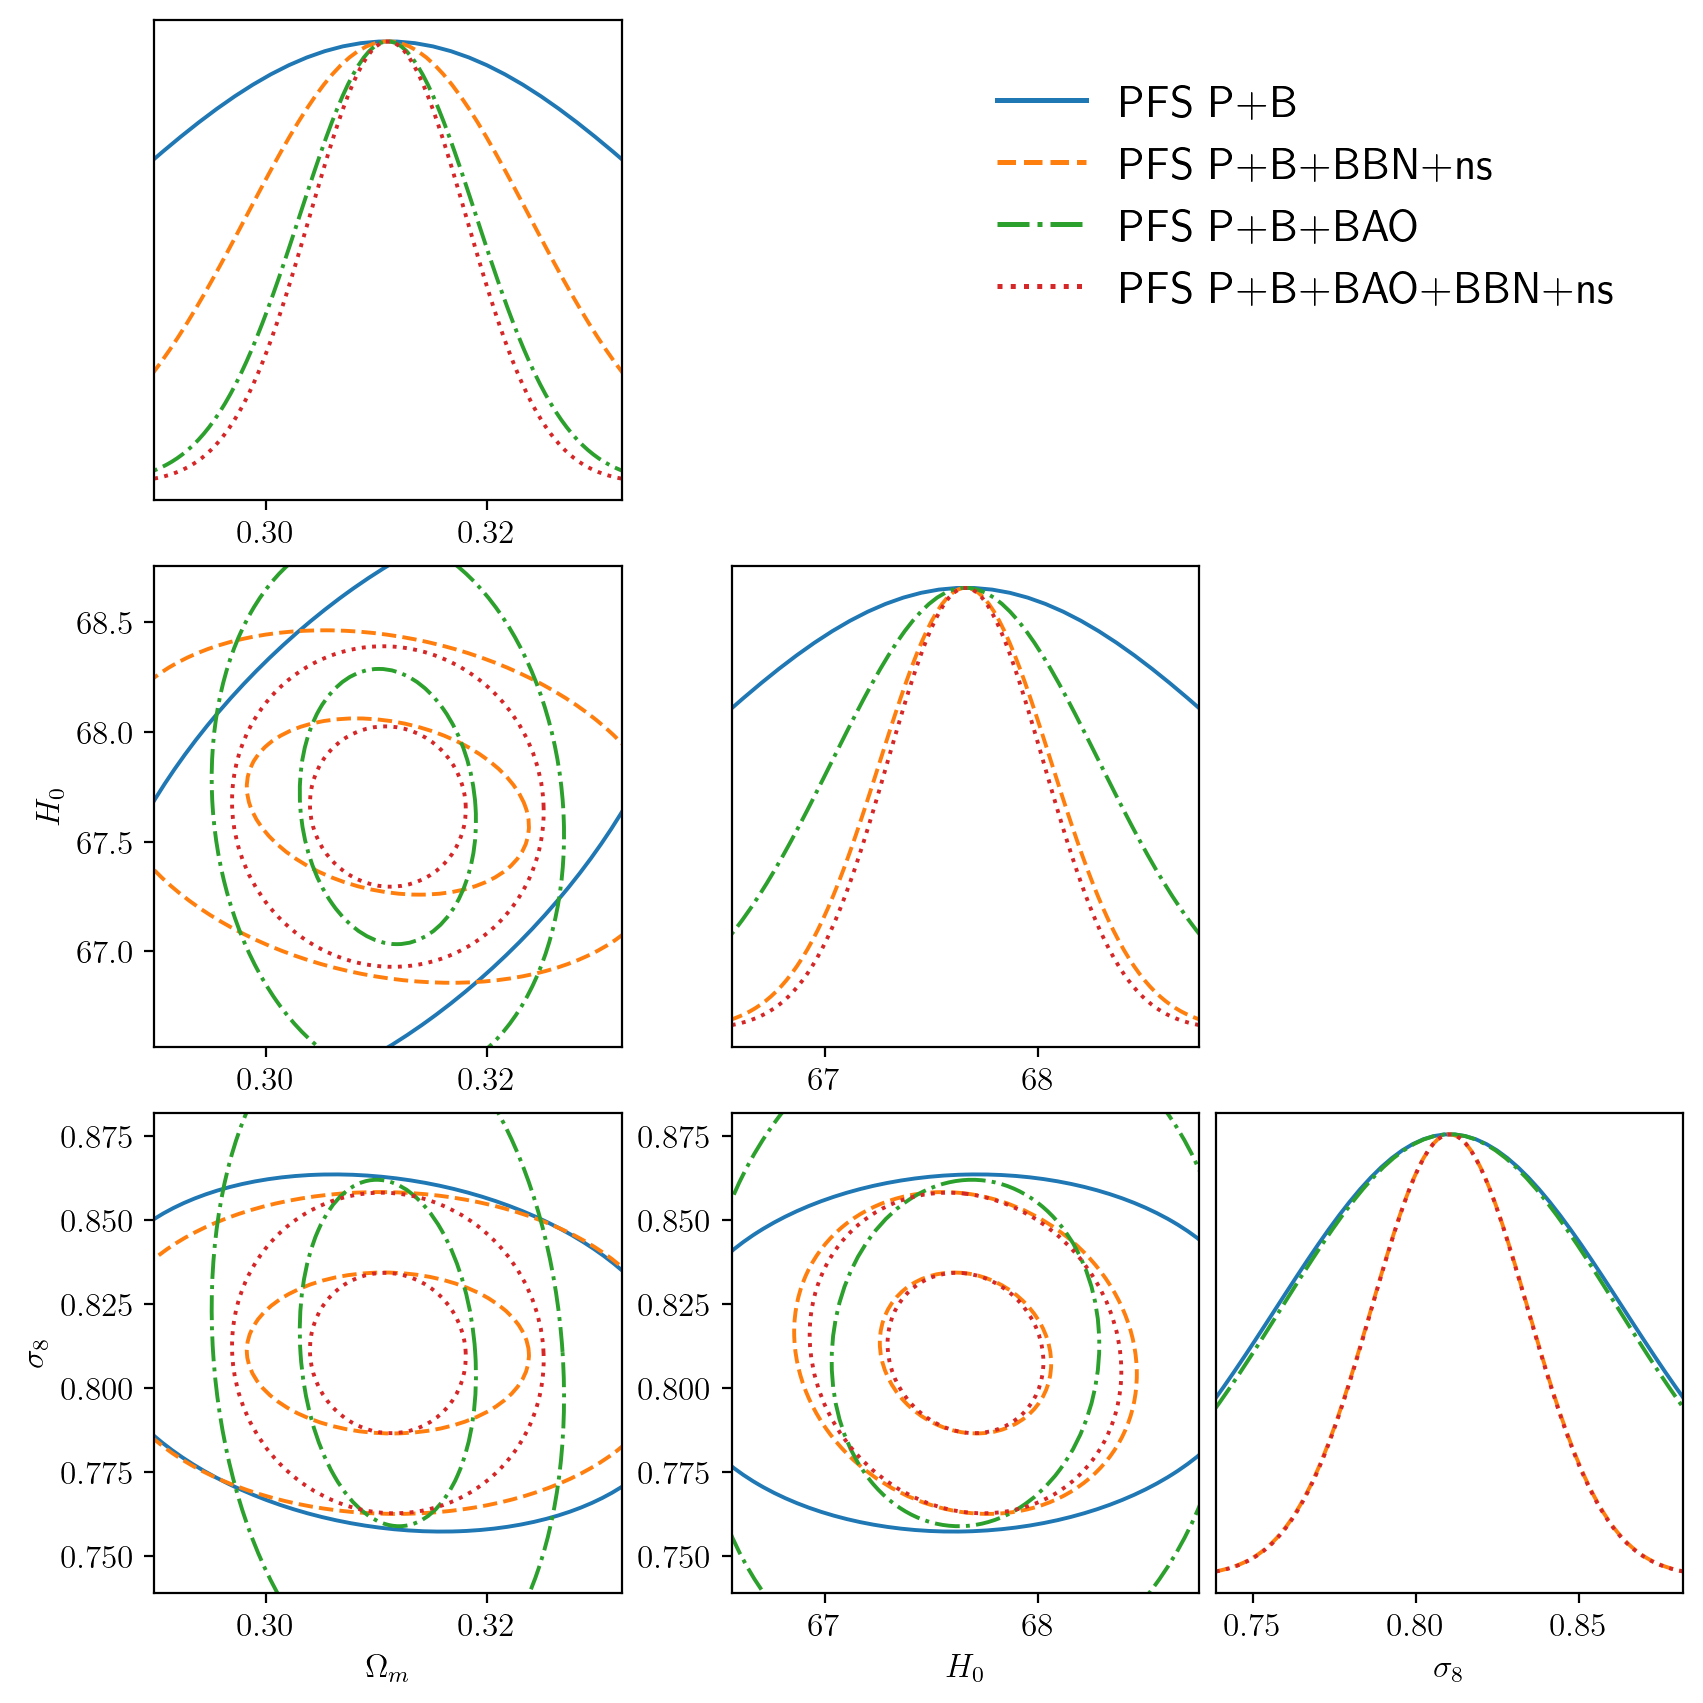

In [10]:
# ── Projected corner plot: Omega_m, H0, sigma8 (+ mnu when varied) ──
proj_colors = plt.cm.tab10(np.linspace(0, 1, 10))
proj_styles = ['-', '--', '-.', ':', '-']

plt.rcParams.update({"font.size": 12})
n_proj = len(selected_param_labels)
fig = plt.figure(figsize=(n_proj * 2.8, n_proj * 2.8), constrained_layout=True)

proj_handles = [
    mlines.Line2D([], [], color=proj_colors[ci],
                  ls=proj_styles[ci % len(proj_styles)], lw=1.8, label=case['label'])
    for ci, case in enumerate(selected_fisher_cases)
]

for i in range(n_proj):
    for j in range(n_proj):
        ax = plt.subplot(n_proj, n_proj, i * n_proj + j + 1)
        if j < i:
            for ci, case in enumerate(selected_fisher_cases):
                F = np.asarray(case['projection'].fisher_plot)
                sub = F[np.ix_([j, i], [j, i])]
                if np.linalg.matrix_rank(sub, tol=1e-10) < 2:
                    continue
                try:
                    plot_contours(
                        F, case['projection'].fid_plot, np.array([j, i]),
                        ax=ax, fill=False, color=proj_colors[ci],
                        ls=proj_styles[ci % len(proj_styles)], lw=1.4,
                    cls=[0.68, 0.95], level_kind="mass2d")
                except Exception:
                    pass
        elif j == i:
            for ci, case in enumerate(selected_fisher_cases):
                F = np.asarray(case['projection'].fisher_plot)
                if F[i, i] < 1e-10:
                    continue
                try:
                    plot_Gaussian(F, case['projection'].fid_plot, i, ax=ax,
                                  color=proj_colors[ci],
                                  ls=proj_styles[ci % len(proj_styles)], lw=1.4)
                except Exception:
                    pass
            ax.set_yticks([])
        else:
            ax.axis('off')
        if i == n_proj - 1:
            ax.set_xlabel(selected_param_labels[j])
        if j == 0 and i > 0:
            ax.set_ylabel(selected_param_labels[i])

fig.legend(handles=proj_handles, loc='upper right', bbox_to_anchor=(0.98, 0.98),
           fontsize=16, frameon=False)

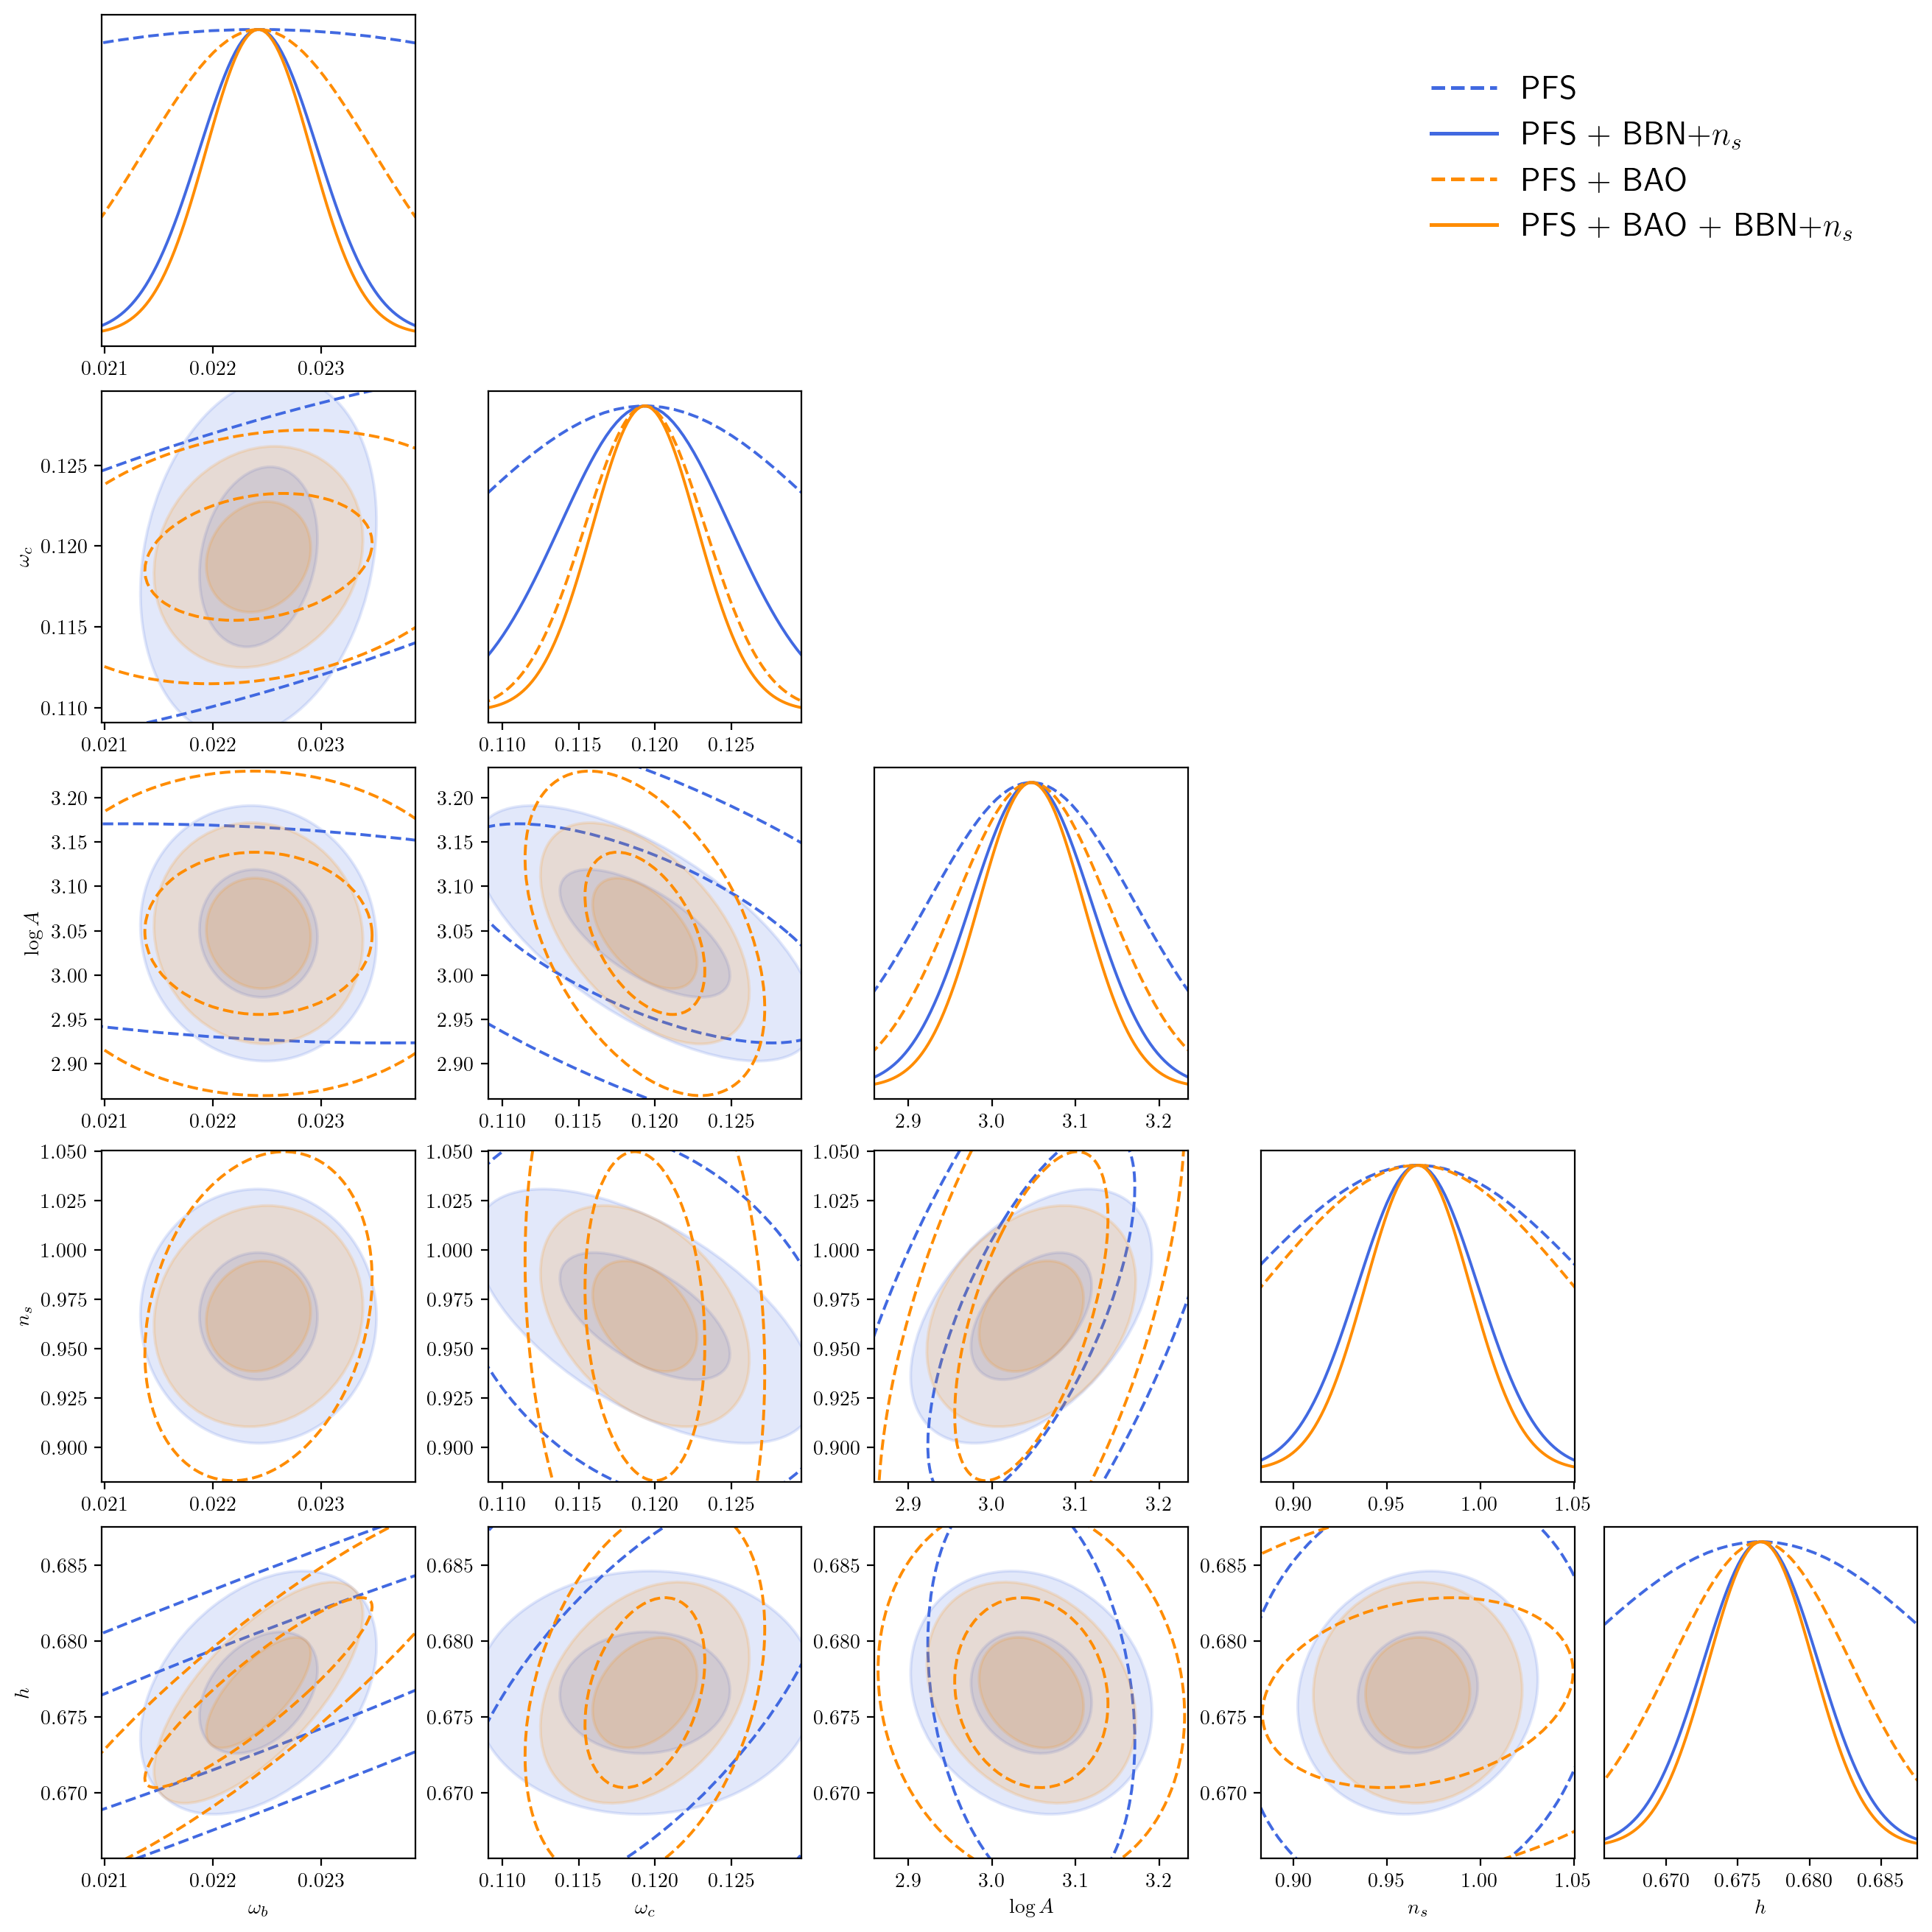

In [11]:
plot_cases = [
    (r'PFS',                     np.asarray(F_pfs_cosmo),           'royalblue',  '--', False),
    (r'PFS + BBN+$n_s$',         np.asarray(F_pfs_prior_cosmo),     'royalblue',  '-',  True),
    (r'PFS + BAO',               np.asarray(F_pfs_bao_cosmo),       'darkorange', '--', False),
    (r'PFS + BAO + BBN+$n_s$',   np.asarray(F_pfs_bao_prior_cosmo), 'darkorange', '-',  True),
]

plt.rcParams.update({"font.size": 10})
fig = plt.figure(figsize=(N_SHARED * 2.6, N_SHARED * 2.6), constrained_layout=True)

legend_handles = [
    mlines.Line2D([], [], color=c, ls=ls, lw=1.8, label=lbl)
    for lbl, _, c, ls, _ in plot_cases
]

for i in range(N_SHARED):
    for j in range(N_SHARED):
        ax = plt.subplot(N_SHARED, N_SHARED, i * N_SHARED + j + 1)

        if j < i:
            for label, F, color, ls, filled in plot_cases:
                sub = F[np.ix_([j, i], [j, i])]
                if np.linalg.matrix_rank(sub, tol=1e-10) < 2:
                    continue
                try:
                    plot_contours(
                        F, FIDUCIAL_SHARED, np.array([j, i]),
                        ax=ax, fill=filled, color=color, ls=ls, lw=1.4,
                        alpha=0.15 if filled else 1.0,
                    cls=[0.68, 0.95], level_kind="mass2d")
                except Exception:
                    pass

        elif j == i:
            for label, F, color, ls, filled in plot_cases:
                if F[i, i] < 1e-10:
                    continue
                try:
                    plot_Gaussian(F, FIDUCIAL_SHARED, i, ax=ax, color=color, ls=ls, lw=1.4)
                except Exception:
                    pass
            ax.set_yticks([])

        else:
            ax.axis('off')

        if i == N_SHARED - 1:
            ax.set_xlabel(SHARED_LABELS[j])
        if j == 0 and i > 0:
            ax.set_ylabel(SHARED_LABELS[i])

fig.legend(handles=legend_handles, loc='upper right', bbox_to_anchor=(0.98, 0.98),
           fontsize=16, frameon=False)

## Fisher diagnostics

In [12]:
print("PFS+BAO+BBN+ns Fisher diagnostics:")
print(format_fisher_diagnostics(fisher_diagnostics(np.asarray(F_pfs_bao_prior_cosmo), param_names=list(SHARED_KEYS))))
print()
print("PFS+BAO Fisher diagnostics:")
print(format_fisher_diagnostics(fisher_diagnostics(np.asarray(F_pfs_bao_cosmo), param_names=list(SHARED_KEYS))))

PFS+BAO+BBN+ns Fisher diagnostics:
rank=5/5, weak_modes=0, cond=3.583e+04, sym_err=0.000e+00, weak_tol=8.957e-04
smallest eigenvalues: 2.500e+02, 1.449e+03, 7.344e+04
null-space participation: logA (0.97)
mode 0 [smallest] eig=2.500e+02: logA (-0.985), ns (-0.167), omch2 (+0.029), h (+0.014)
mode 1 [smallest] eig=1.449e+03: ns (-0.985), logA (+0.168), omch2 (+0.026), h (-0.017)
mode 2 [smallest] eig=7.344e+04: h (-0.907), omch2 (-0.411), ombh2 (-0.088), logA (-0.026)

PFS+BAO Fisher diagnostics:
rank=5/5, weak_modes=0, cond=6.724e+04, sym_err=0.000e+00, weak_tol=5.470e-04
smallest eigenvalues: 8.135e+01, 3.294e+02, 2.812e+04
null-space participation: logA (0.58), ns (0.42)
mode 0 [smallest] eig=8.135e+01: logA (-0.762), ns (-0.648), omch2 (+0.013), h (-0.002)
mode 1 [smallest] eig=3.294e+02: ns (-0.761), logA (+0.647), h (-0.044), omch2 (-0.022)
mode 2 [smallest] eig=2.812e+04: h (-0.960), omch2 (-0.233), ombh2 (-0.149), ns (+0.036)
